# Hamiltonian Monte Carlo and sampler diagnostics

CPU companion; no accelerator is required. TPU execution not validated.

- Implement leapfrog with the correct half-step boundaries
- Check reversibility and an independent analytic gradient
- Compare four seeded chains with a known posterior
- Interpret energy error, acceptance and classical split R-hat without claiming convergence

An approximate inference program returns a long list of weights. Before treating those weights as posterior samples, how can we tell whether its mechanics are correct and whether its chains explored the target? We will build a transparent Hamiltonian Monte Carlo sampler for a correlated Gaussian with a known mean and covariance, then deliberately damage its step size.

## The idea

Hamiltonian Monte Carlo introduces momentum to propose distant states while accounting for the target density. Numerical integration and acceptance control the proposal, but diagnostics are still needed to judge whether the retained samples explore the posterior adequately.

## A moving chain is not automatically a well-mixed chain

Follow position and momentum through a leapfrog trajectory. A proposal can travel far without behaving like an independent posterior draw. Integration error and acceptance behavior provide one diagnostic, while between-chain agreement and autocorrelation provide others.

Start multiple chains from meaningfully different positions where appropriate. Inspect the same retained sampling region across chains, and separate adaptation from retained draws. A trace that looks active may still stay in one region or be strongly correlated.

The lesson's trace plot uses a known posterior mean as a reference. Matching that mean is not sufficient: spread and dependence matter too. Compute diagnostics from the retained samples with their conventions recorded; plotting a thinned subset should not silently redefine the diagnostic sample.

### Pause and reason

Why can many saved samples still provide little effective information?

<details><summary>Compare your reasoning</summary>

Strong dependence or poor exploration can make them redundant. Sample count and effective sample size answer different questions; neither a smooth trace nor a correct mean alone establishes adequate mixing.

</details>

## Turn log-density into potential energy

For a normal target with mean $m$ and covariance $\Sigma$, the potential is $U(q)=(q-m)^\top\Sigma^{-1}(q-m)/2$, ignoring a constant. Its gradient is $\Sigma^{-1}(q-m)$, so we have an independent formula for autodiff. Momentum has a standard-normal distribution and kinetic energy $p^\top p/2$. The combined energy should remain constant along an exact trajectory.

$$
H(q,p)=U(q)+\tfrac12p^\top p,\qquad \nabla U(q)=\Sigma^{-1}(q-m)
$$

## Trace the half steps

First take a half momentum step using the current gradient. Take a full position step with that momentum, then update momentum using the new position. Interior momentum steps are full steps; the final one is a half step. This symmetry gives a reversible integrator up to numerical error. Our check negates the final momentum and integrates again; it should return to the starting position and negative starting momentum. A loop with all full momentum steps fails that boundary test.

## Correct discretization error in log space

A proposed trajectory changes energy by $\Delta H$. Accept with probability $\min(1,e^{-\Delta H})$, implemented as $\log u<-\Delta H$. A rejected proposal retains the current sample; removing repeated values would change the distribution. Non-finite energy error is rejected. The signed energy error can be negative, so it should not be interpreted as a nonnegative loss. An enormous positive error suggests an integration problem, often a step size too large for target curvature.

## Read diagnostics as evidence, not a certificate

We start four chains from dispersed points and discard the first $400$ transitions. This fixed discard is a teaching convention, not automatic warmup adaptation. Classical split R-hat compares between-chain and within-chain variance after splitting each chain. A value near one says those variance estimates agree; chains can still miss a mode together. Modern rank-normalized split R-hat, bulk and tail effective sample size, Monte Carlo standard errors and divergence diagnostics are stronger complementary tools. Our compact implementation is explicitly classical R-hat and does not implement those modern diagnostics.

## Use the reference model to expose failure

Here the exact mean, variance and covariance are known. Check all of them: getting both marginal means right can still hide missing correlation. Acceptance alone is insufficient; a tiny step can accept almost everything while exploring slowly. Effective sample size concerns the information in correlated draws, not the number of rows stored. Before using a library such as NumPyro on an unknown posterior, repeat an exact-model validation and inspect its documented diagnostics. This CPU fixture establishes neither multimodal exploration nor accelerator performance.

## 1. Write a known target and its gradient

Create a fresh main.py. This correlated Gaussian is an exact test target for an inference algorithm, not a new unknown statistical model.

In [1]:
# Step 1 — 1. Write a known target and its gradient: Potential energy is the negative log-density up to a constant,...
# Import numpy for this computation.
import numpy as np
import jax
import jax.numpy as jnp
# Initialize array `target_mean` with explicit values and shape.
target_mean = jnp.array([1.,-1.])
# Initialize array `target_cov` with explicit values and shape.
target_cov = jnp.array([[1.,.8],[.8,1.]])
# Initialize array `precision` with explicit values and shape.
precision = jnp.linalg.solve(target_cov,jnp.eye(2))
# Function `potential(q)` implementing this stage's computation:
def potential(q):
    # Evaluate `delta` from the current inputs and state.
    delta=q-target_mean
    # Return `0.5 * delta @ precision @ delta` to the caller.
    return .5*delta@precision@delta
# Differentiate the objective to obtain `force` via automatic differentiation.
force=jax.grad(potential)
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(force(jnp.array([0.,0.])),precision@(-target_mean))

Potential energy is the negative log-density up to a constant, which cancels in the acceptance ratio.

## 2. Integrate then accept or reject

Append a leapfrog trajectory and a chain. Every transition splits keys for momentum and acceptance; rejection retains the old position.

In [2]:
# Step 2 — 2. Integrate then accept or reject: Leapfrog approximates energy conservation.
def leapfrog(q,p,step_size,steps):
    # Evaluate `p` from the current inputs and state.
    p=p-.5*step_size*force(q)
    # Function `step(i, state)` implementing this stage's computation:
    def step(i,state):
        # Evaluate `(q, p)` from the current inputs and state.
        q,p=state
        # Evaluate `q` from the current inputs and state.
        q=q+step_size*p
        # Combine or mask array elements to form `p`.
        p=p-jnp.where(i<steps-1,step_size,.5*step_size)*force(q)
        # Return `(q, p)` to the caller.
        return q,p
    # Return `jax.lax.fori_loop(0, steps, step, (q, p))` to the caller.
    return jax.lax.fori_loop(0,steps,step,(q,p))

# Define `chain(key, initial, step_size, leapfrog_steps...)` to carry state across steps with `jax.lax.scan`:
def chain(key,initial,step_size=.25,leapfrog_steps=7,draws=1600):
    # Function `transition(state, _)` implementing this stage's computation:
    def transition(state,_):
        # Evaluate `(q, key)` from the current inputs and state.
        q,key=state
        # Create or split explicit PRNG key(s) (`(key, kp, ku)`) for reproducible randomness.
        key,kp,ku=jax.random.split(key,3)
        # Sample deterministic random values into `p` using an explicit PRNG key.
        p=jax.random.normal(kp,q.shape)
        # Run `leapfrog` to compute `(proposal, new_p)`.
        proposal,new_p=leapfrog(q,p,step_size,leapfrog_steps)
        # Reduce across the target axis to summarize `error`.
        error=potential(proposal)+.5*jnp.sum(new_p**2)-potential(q)-.5*jnp.sum(p**2)
        # Draw pseudorandom samples for `accept` using the explicit RNG state.
        accept=jnp.isfinite(error)&(jnp.log(jax.random.uniform(ku)) < -error)
        # Combine or mask array elements to form `next_q`.
        next_q=jnp.where(accept,proposal,q)
        # Return `((next_q, key), (next_q, accept, error))` to the caller.
        return (next_q,key),(next_q,accept,error)
    # Run compiled structured control flow via `jax.lax` (`(_, record)`).
    _,record=jax.lax.scan(transition,(initial,key),None,length=draws)
    # Return `record` to the caller.
    return record

Leapfrog approximates energy conservation. Metropolis correction removes integration bias in the ideal stationary distribution; it does not make a finite chain independent or guarantee exploration.

## 3. Compare chains and an analytic oracle

Append four dispersed starts, discard an explicitly fixed initial segment, and retain all diagnostics. Run python main.py.

In [3]:
# Step 3 — 3. Compare chains and an analytic oracle: The tolerances test this seeded Gaussian fixture only.
# Initialize array `starts` with explicit values and shape.
starts=jnp.array([[-4.,-4.],[-4.,4.],[4.,-4.],[4.,4.]])
# Create or split explicit PRNG key(s) (`records`) for reproducible randomness.
records=jax.vmap(lambda key,start:chain(key,start))(jax.random.split(jax.random.key(71),4),starts)
# Evaluate `samples` from the current inputs and state.
samples=records[0][:,400:,:]
# Function `split_rhat(values)` implementing this stage's computation:
def split_rhat(values):
    # Classical split R-hat for one scalar coordinate; not rank-normalized.
    half=values.shape[1]//2
    # Combine or mask array elements to form `split`.
    split=jnp.concatenate([values[:,:half],values[:,-half:]],axis=0)
    # Reduce along axis=1 to compute `within`.
    within=jnp.var(split,axis=1,ddof=1).mean()
    # Reduce along axis=1 to compute `between`.
    between=half*jnp.var(split.mean(axis=1),ddof=1)
    # Return `jnp.sqrt(((half - 1) * within / half + between / half) / within)` to the caller.
    return jnp.sqrt(((half-1)*within/half+between/half)/within)
# Vectorize across the batch dimension with `jax.vmap` (`rhats`).
rhats=jax.vmap(split_rhat,in_axes=2)(samples)
# Construct and reshape `pooled` into the target tensor dimensions.
pooled=samples.reshape(-1,2)
# Verify contract: `jnp.max(jnp.abs(pooled.mean(0) - target_mean)) < 0.15`.
assert jnp.max(jnp.abs(pooled.mean(0)-target_mean))<.15
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.max(jnp.abs(jnp.cov(pooled.T)-target_cov))<.2
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.all(rhats<1.05)
# Print the observed values to compare against the expected result.
print('mean:',pooled.mean(0),'covariance:',jnp.cov(pooled.T))
# Print diagnostic summary of the computed outputs.
print('classical split R-hat:',rhats,'acceptance:',records[1].mean(axis=1))

mean: [ 0.98358583 -1.0185838 ] covariance: [[0.98042357 0.7727629 ]
 [0.7727629  0.9861013 ]]
classical split R-hat: [1.0002148 1.000253 ] acceptance: [0.97749996 0.98625    0.98125    0.980625  ]


The tolerances test this seeded Gaussian fixture only. Agreement with a known posterior is stronger evidence here than a diagnostic threshold alone.

## Run the example

In [4]:
# Step 1 — 1. Write a known target and its gradient: Potential energy is the negative log-density up to a constant,...
# Import numpy for this computation.
import numpy as np
import jax
import jax.numpy as jnp
# Initialize array `target_mean` with explicit values and shape.
target_mean = jnp.array([1.,-1.])
# Initialize array `target_cov` with explicit values and shape.
target_cov = jnp.array([[1.,.8],[.8,1.]])
# Initialize array `precision` with explicit values and shape.
precision = jnp.linalg.solve(target_cov,jnp.eye(2))
# Function `potential(q)` implementing this stage's computation:
def potential(q):
    # Evaluate `delta` from the current inputs and state.
    delta=q-target_mean
    # Return `0.5 * delta @ precision @ delta` to the caller.
    return .5*delta@precision@delta
# Differentiate the objective to obtain `force` via automatic differentiation.
force=jax.grad(potential)
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(force(jnp.array([0.,0.])),precision@(-target_mean))

# Step 2 — 2. Integrate then accept or reject: Leapfrog approximates energy conservation.
def leapfrog(q,p,step_size,steps):
    # Evaluate `p` from the current inputs and state.
    p=p-.5*step_size*force(q)
    # Function `step(i, state)` implementing this stage's computation:
    def step(i,state):
        # Evaluate `(q, p)` from the current inputs and state.
        q,p=state
        # Evaluate `q` from the current inputs and state.
        q=q+step_size*p
        # Combine or mask array elements to form `p`.
        p=p-jnp.where(i<steps-1,step_size,.5*step_size)*force(q)
        # Return `(q, p)` to the caller.
        return q,p
    # Return `jax.lax.fori_loop(0, steps, step, (q, p))` to the caller.
    return jax.lax.fori_loop(0,steps,step,(q,p))

# Define `chain(key, initial, step_size, leapfrog_steps...)` to carry state across steps with `jax.lax.scan`:
def chain(key,initial,step_size=.25,leapfrog_steps=7,draws=1600):
    # Function `transition(state, _)` implementing this stage's computation:
    def transition(state,_):
        # Evaluate `(q, key)` from the current inputs and state.
        q,key=state
        # Create or split explicit PRNG key(s) (`(key, kp, ku)`) for reproducible randomness.
        key,kp,ku=jax.random.split(key,3)
        # Sample deterministic random values into `p` using an explicit PRNG key.
        p=jax.random.normal(kp,q.shape)
        # Run `leapfrog` to compute `(proposal, new_p)`.
        proposal,new_p=leapfrog(q,p,step_size,leapfrog_steps)
        # Reduce across the target axis to summarize `error`.
        error=potential(proposal)+.5*jnp.sum(new_p**2)-potential(q)-.5*jnp.sum(p**2)
        # Draw pseudorandom samples for `accept` using the explicit RNG state.
        accept=jnp.isfinite(error)&(jnp.log(jax.random.uniform(ku)) < -error)
        # Combine or mask array elements to form `next_q`.
        next_q=jnp.where(accept,proposal,q)
        # Return `((next_q, key), (next_q, accept, error))` to the caller.
        return (next_q,key),(next_q,accept,error)
    # Run compiled structured control flow via `jax.lax` (`(_, record)`).
    _,record=jax.lax.scan(transition,(initial,key),None,length=draws)
    # Return `record` to the caller.
    return record

# Step 3 — 3. Compare chains and an analytic oracle: The tolerances test this seeded Gaussian fixture only.
# Initialize array `starts` with explicit values and shape.
starts=jnp.array([[-4.,-4.],[-4.,4.],[4.,-4.],[4.,4.]])
# Create or split explicit PRNG key(s) (`records`) for reproducible randomness.
records=jax.vmap(lambda key,start:chain(key,start))(jax.random.split(jax.random.key(71),4),starts)
# Evaluate `samples` from the current inputs and state.
samples=records[0][:,400:,:]
# Function `split_rhat(values)` implementing this stage's computation:
def split_rhat(values):
    # Classical split R-hat for one scalar coordinate; not rank-normalized.
    half=values.shape[1]//2
    # Combine or mask array elements to form `split`.
    split=jnp.concatenate([values[:,:half],values[:,-half:]],axis=0)
    # Reduce along axis=1 to compute `within`.
    within=jnp.var(split,axis=1,ddof=1).mean()
    # Reduce along axis=1 to compute `between`.
    between=half*jnp.var(split.mean(axis=1),ddof=1)
    # Return `jnp.sqrt(((half - 1) * within / half + between / half) / within)` to the caller.
    return jnp.sqrt(((half-1)*within/half+between/half)/within)
# Vectorize across the batch dimension with `jax.vmap` (`rhats`).
rhats=jax.vmap(split_rhat,in_axes=2)(samples)
# Construct and reshape `pooled` into the target tensor dimensions.
pooled=samples.reshape(-1,2)
# Verify contract: `jnp.max(jnp.abs(pooled.mean(0) - target_mean)) < 0.15`.
assert jnp.max(jnp.abs(pooled.mean(0)-target_mean))<.15
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.max(jnp.abs(jnp.cov(pooled.T)-target_cov))<.2
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.all(rhats<1.05)
# Print the observed values to compare against the expected result.
print('mean:',pooled.mean(0),'covariance:',jnp.cov(pooled.T))
# Print diagnostic summary of the computed outputs.
print('classical split R-hat:',rhats,'acceptance:',records[1].mean(axis=1))

mean: [ 0.98358583 -1.0185838 ] covariance: [[0.98042357 0.7727629 ]
 [0.7727629  0.9861013 ]]
classical split R-hat: [1.0002148 1.000253 ] acceptance: [0.97749996 0.98625    0.98125    0.980625  ]


Expected: The pooled mean and covariance approach the stated target within the fixture tolerances. The two classical split R-hat values, one per parameter coordinate, remain near $1$; acceptance is reported separately for each chain.

## Four HMC traces around a known posterior mean

Predict: Can the chains cross the known mean while still showing successive correlated values?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
# Compute figure data for: Four HMC traces around a known posterior mean
# Create evenly spaced index values in `indices`.
indices=np.arange(0,400,10)
# Convert `visual_data` to a host NumPy array for inspection or verification.
visual_data={"kind":"line","x":indices.tolist(),"xlabel":"retained transition (after fixed discard)","ylabel":"first parameter coordinate","series":[{"label":"chain "+str(i+1),"y":np.asarray(samples[i,indices,0]).tolist()} for i in range(4)]}

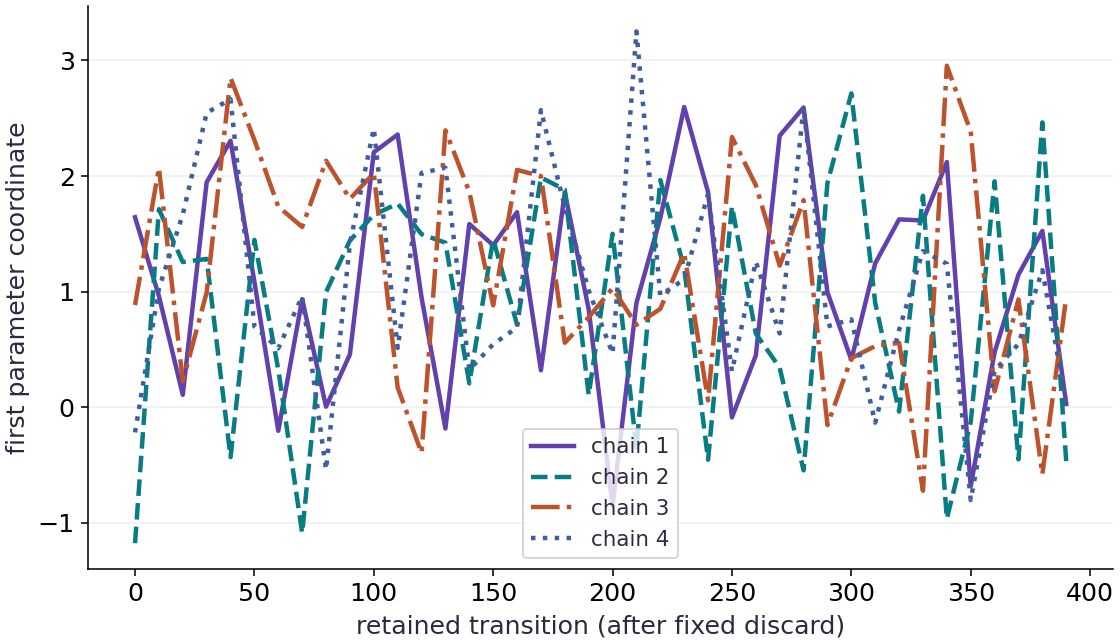

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The horizontal axis counts retained transitions after discarding the initial $400$. The vertical axis is the first coordinate of the sampled parameter. Each colored line is one chain, plotted at every tenth retained transition to keep the figure readable. The target mean is $1$; the chains move on both sides of it. Their paths differ because they use different keys and initial positions. Connecting thinned points helps visual inspection but does not make the underlying draws independent.

### Connect it to the computation

This trace is one piece of the evidence. The code also checks the two-dimensional covariance, which a single-coordinate trace cannot show, and prints classical split R-hat and acceptance. A smooth-looking trace or repeated crossings of the mean cannot establish exploration of modes absent from this single-Gaussian fixture.

## Reverse one trajectory

Predict: If we reverse momentum after a trajectory, should the integrator return to the starting position?

In [7]:
# Experiment — Reverse one trajectory: Reversibility is an integrator invariant, independent of whether...
# Initialize array `q0` with explicit values and shape.
q0=jnp.array([.2,-.4]);p0=jnp.array([.3,.7])
# Run `leapfrog` to compute `(q1, p1)`.
q1,p1=leapfrog(q0,p0,.15,9)
# Run `leapfrog` to compute `(q2, p2)`.
q2,p2=leapfrog(q1,-p1,.15,9)
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(q2,q0,atol=2e-6)
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(p2,-p0,atol=2e-6)

Expected: The reversed trajectory returns within float32 tolerance.

Reversibility is an integrator invariant, independent of whether a particular chain happened to get a plausible mean.

## Separate replay from a changed chain

Predict: Will changing a key change the sampled path while leaving the target unchanged?

In [8]:
# Experiment — Separate replay from a changed chain: Replay tests state ownership.
# Create or split explicit PRNG key(s) (`replay`) for reproducible randomness.
replay=chain(jax.random.key(9),jnp.zeros(2),draws=50)[0]
# Create or split explicit PRNG key(s) (`again`) for reproducible randomness.
again=chain(jax.random.key(9),jnp.zeros(2),draws=50)[0]
# Create or split explicit PRNG key(s) (`changed`) for reproducible randomness.
changed=chain(jax.random.key(10),jnp.zeros(2),draws=50)[0]
# Verify contract: `jnp.array_equal(replay, again)`.
assert jnp.array_equal(replay,again)
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert not jnp.array_equal(replay,changed)

Expected: The same key reproduces the path; another key produces a different path.

Replay tests state ownership. It does not establish distributional correctness by itself.

## Your exercise

Increase the step size to 1.2 with the same leapfrog count. Record acceptance and positive energy errors. Explain why keeping more rejected samples is not a repair for unstable integration.

### How to write this exercise — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `x.sum(axis=...) / x.mean(axis=..., keepdims=...)` — Reduces values along the named `axis` (the axis you name is collapsed unless `keepdims=True`).
- `jax.random.PRNGKey(seed) & jax.random.split(key)` — Manages explicit, stateless PRNG keys—always split a key before passing subkeys into independent random draws.

**Step-by-step implementation plan:**
1. Create or split explicit PRNG key(s) (`bad`) for reproducible randomness.
2. Verify contract: `bad[1].mean() < 0.2`.
3. Verify that the output satisfies the expected shape, finite-value, or numerical contract.
4. Print the observed values to compare against the expected result.

**Starter code scaffold (fill in the TODOs):**

```python
# Exercise solution: Increase the step size to 1.2 with the same leapfrog count.
# Create or split explicit PRNG key(s) (`bad`) for reproducible randomness.
bad = chain(...)  # TODO: compute bad
# Verify contract: `bad[1].mean() < 0.2`.
assert bad[1].mean()  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.max(bad[2])  # TODO: complete assertion check
# Print the observed values to compare against the expected result.
print("bad acceptance:",float(bad[1].mean()),"maximum energy error:",float(jnp.max(bad[2])))
```

In [9]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Exercise solution: Increase the step size to 1.2 with the same leapfrog count.
# Create or split explicit PRNG key(s) (`bad`) for reproducible randomness.
# bad = chain(...)  # TODO: compute bad
# Verify contract: `bad[1].mean() < 0.2`.
# assert bad[1].mean()  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
# assert jnp.max(bad[2])  # TODO: complete assertion check
# Print the observed values to compare against the expected result.
# print("bad acceptance:",float(bad[1].mean()),"maximum energy error:",float(jnp.max(bad[2])))

## Reference solution

Try your own implementation first.

In [10]:
# Exercise solution: Increase the step size to 1.2 with the same leapfrog count.
# Create or split explicit PRNG key(s) (`bad`) for reproducible randomness.
bad=chain(jax.random.key(71),starts[0],step_size=1.2,draws=100)
# Verify contract: `bad[1].mean() < 0.2`.
assert bad[1].mean()<.2
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.max(bad[2])>100.
# Print the observed values to compare against the expected result.
print("bad acceptance:",float(bad[1].mean()),"maximum energy error:",float(jnp.max(bad[2])))

bad acceptance: 0.0 maximum energy error: 50229501952.0


## Catch chains trapped at different levels · Transfer / diagnosis

Construct four arrays with similar within-chain variation but means separated by four units. Verify that classical split R-hat flags disagreement.

Hint: Use independent small noise around four different constants.

### How to write: Catch chains trapped at different levels — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.arange(n, dtype=...)` — Creates a 1-D JAX array of evenly spaced values `[0, 1, ..., n-1]` on the target device.
- `jax.random.PRNGKey(seed) & jax.random.split(key)` — Manages explicit, stateless PRNG keys—always split a key before passing subkeys into independent random draws.

**Step-by-step implementation plan:**
1. Create or split explicit PRNG key(s) (`fake`) for reproducible randomness.
2. Verify contract: `split_rhat(fake) > 5`.

**Starter code scaffold (fill in the TODOs):**

```python
# Catch chains trapped at different levels (Transfer / diagnosis): Between-chain variation dominates within-chain variation, so...
# Create or split explicit PRNG key(s) (`fake`) for reproducible randomness.
fake = jax.random.normal(...)  # TODO: compute fake
# Verify contract: `split_rhat(fake) > 5`.
assert split_rhat(fake)  # TODO: complete assertion check
```

In [11]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Catch chains trapped at different levels (Transfer / diagnosis): Between-chain variation dominates within-chain variation, so...
# Create or split explicit PRNG key(s) (`fake`) for reproducible randomness.
# fake = jax.random.normal(...)  # TODO: compute fake
# Verify contract: `split_rhat(fake) > 5`.
# assert split_rhat(fake)  # TODO: complete assertion check

## Reference reasoning

Between-chain variation dominates within-chain variation, so pooling would conceal a serious exploration problem.

In [12]:
# Catch chains trapped at different levels (Transfer / diagnosis): Between-chain variation dominates within-chain variation, so...
# Create or split explicit PRNG key(s) (`fake`) for reproducible randomness.
fake=jax.random.normal(jax.random.key(4),(4,600))*.1+jnp.arange(4)[:,None]*4
# Verify contract: `split_rhat(fake) > 5`.
assert split_rhat(fake)>5

## Verify a directional derivative · Transfer / diagnosis

At a nonzero position compare the autodiff directional derivative with the analytic precision-matrix expression. Then compare to a central difference.

Hint: Use the same direction and a moderate float32 finite-difference step.

### How to write: Verify a directional derivative — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.array(values, dtype=...)` — Constructs an immutable device-backed JAX array from Python/NumPy values.
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.

**Step-by-step implementation plan:**
1. Initialize array `q` with explicit values and shape.
2. Perform matrix / vector contraction (`@`) to compute `analytic`.
3. Perform matrix / vector contraction (`@`) to compute `auto`.
4. Evaluate `finite` from the current inputs and state.
5. Verify that computed values match the expected reference within numerical tolerance.

**Starter code scaffold (fill in the TODOs):**

```python
# Verify a directional derivative (Transfer / diagnosis): A sign error in potential or a transposed geometry can be...
# Initialize array `q` with explicit values and shape.
q = jnp.array(...)  # TODO: compute q
# Perform matrix / vector contraction (`@`) to compute `analytic`.
analytic = ...  # TODO: compute analytic
# Perform matrix / vector contraction (`@`) to compute `auto`.
auto = force(...)  # TODO: compute auto
# Evaluate `finite` from the current inputs and state.
finite = ...  # TODO: compute finite
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(auto,analytic,rtol = ...  # TODO: compute np.testing.assert_allclose(auto,analytic,rtol
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(finite,analytic,rtol = ...  # TODO: compute np.testing.assert_allclose(finite,analytic,rtol
```

In [13]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Verify a directional derivative (Transfer / diagnosis): A sign error in potential or a transposed geometry can be...
# Initialize array `q` with explicit values and shape.
# q = jnp.array(...)  # TODO: compute q
# Perform matrix / vector contraction (`@`) to compute `analytic`.
# analytic = ...  # TODO: compute analytic
# Perform matrix / vector contraction (`@`) to compute `auto`.
# auto = force(...)  # TODO: compute auto
# Evaluate `finite` from the current inputs and state.
# finite = ...  # TODO: compute finite
# Verify that computed values match the expected reference within numerical tolerance.
# np.testing.assert_allclose(auto,analytic,rtol = ...  # TODO: compute np.testing.assert_allclose(auto,analytic,rtol
# Verify that computed values match the expected reference within numerical tolerance.
# np.testing.assert_allclose(finite,analytic,rtol = ...  # TODO: compute np.testing.assert_allclose(finite,analytic,rtol

## Reference reasoning

A sign error in potential or a transposed geometry can be isolated before tuning the sampler.

In [14]:
# Verify a directional derivative (Transfer / diagnosis): A sign error in potential or a transposed geometry can be...
# Initialize array `q` with explicit values and shape.
q=jnp.array([.4,.8]);v=jnp.array([.7,-.2]);eps=.001
# Perform matrix / vector contraction (`@`) to compute `analytic`.
analytic=(precision@(q-target_mean))@v
# Perform matrix / vector contraction (`@`) to compute `auto`.
auto=force(q)@v
# Evaluate `finite` from the current inputs and state.
finite=(potential(q+eps*v)-potential(q-eps*v))/(2*eps)
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(auto,analytic,rtol=1e-6)
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(finite,analytic,rtol=.005,atol=.002)

## Checkpoint

Four chains have classical split R-hat close to one. What can we conclude?

1. They have certainly explored every posterior mode
2. Their retained draws are independent
3. Their within-chain and between-chain variance estimates agree, but additional checks are still necessary

## Diagnose

If acceptance collapses, inspect the finite energy error distribution and reduce the step size. If acceptance is high but traces barely move, inspect trajectory length and autocorrelation. If chains disagree, retain separate traces rather than pooling them into a smooth histogram. If a constant chain produces undefined R-hat, report that failure instead of replacing it with one.

## Evidence

Reversibility check, four traces, two-dimensional moments, key replay and classical split R-hat with limitations. Keep the environment, observed outputs and your explanation of the figure.

## Carry forward

- A correct accept/reject rule retains rejected states.
- Check integrator invariants before interpreting chains.
- Near-one R-hat and high acceptance are useful evidence, not proof of convergence.

## Primary references

- [JAX scan state contract](https://docs.jax.dev/en/latest/_autosummary/jax.lax.scan.html)
- [Stan posterior analysis and diagnostics](https://mc-stan.org/docs/reference-manual/analysis.html)
- [NumPyro MCMC diagnostics interface](https://num.pyro.ai/en/stable/diagnostics.html)